In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

In [3]:
DP = DP()
dps_df, model_1comp, left_2comp, right_2comp = DP.extract_fits_data('./catalogs/all_catalog_test.fits')

In [4]:
DP_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=dps_df['TARGETID'].to_list())
DP_SPECTRA = DP_SPECTRA.stack_data()
DP_SPECTRA = DP_SPECTRA.shift_to_rest_frame()

In [538]:
example_df = dps_df[dps_df['TARGETID']==39627788189175974].iloc[0]
example_idx = DP_SPECTRA.id2index(example_df['TARGETID'])
lam, flux, ivar = DP_SPECTRA.data_stack[example_idx, 0, :], DP_SPECTRA.data_stack[example_idx, 1, :], DP_SPECTRA.data_stack[example_idx, 2, :]
sigma = 1/np.sqrt(np.abs(ivar))


/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_57433/1028261939.py:4: RuntimeWarning: divide by zero encountered in divide
  sigma = 1/np.sqrt(np.abs(ivar))


In [539]:
test_1comp = model_1comp[example_idx]
test_2comp_l = left_2comp[example_idx]
test_2comp_r = right_2comp[example_idx]
test_2comp = test_2comp_l + test_2comp_r

In [540]:
example_df

TARGETID         39627788189175974
RA                      206.441452
DEC                      -0.070261
Z                         0.253147
LOGM                     10.866252
LOGSFR                    1.388264
dv_r                    143.689224
dv_l                    -79.941612
sigma_r                  59.192802
sigma_l                  99.726982
sigma_1comp             149.329239
p_value                        0.0
OII3726_dp                   False
OII3729_dp                   False
Hbeta_dp                     False
OIII4959_dp                  False
OIII5007_dp                  False
NII6548_dp                   False
Halpha_dp                     True
NII6583_dp                    True
SII6716_dp                   False
SII6731_dp                   False
OII3726_rank                     7
OII3729_rank                     6
Hbeta_rank                       2
OIII4959_rank                    9
OIII5007_rank                    8
NII6548_rank                     4
Halpha_rank         

In [541]:
lam_mask = (lam > NaD_rest[0]-20) & (lam < NaD_rest[1]+20)
crop_lam = lam[lam_mask]
crop_flux = flux[lam_mask]
crop_sigma = sigma[lam_mask]


def fitting_func(lam, A1, A2, A3, A4, dv, sigma_1, sigma_2, a, b):
    flux = 0
    gaussiam_params = [(A1, NaD_rest[0], dv, sigma_1), (A2, NaD_rest[1], dv, sigma_1), (A3, NaD_rest[0], 0, sigma_2), (A4, NaD_rest[1], 0, sigma_2)]
    model = model_vel(lam, gaussiam_params, (a, b))
    return model

p0 = [-3, -2,-3, -2, 0, 120, 120, 0, 0]  # Initial guess for A1, A2, dv, sigma
bound_upper = [0, 0, 0, 0, 300, 300, 300, np.inf, 20]
bound_lower = [-np.inf, -np.inf, -np.inf, -np.inf, -300, 0, 0, -np.inf, -20]

popt, pcov = curve_fit(fitting_func, crop_lam, crop_flux, p0=p0, sigma=crop_sigma, bounds=(bound_lower, bound_upper), absolute_sigma=True)


In [542]:
# lam_mask = (lam > NaD_rest[0]-15) & (lam < NaD_rest[1]+15)
# crop_lam = lam[lam_mask]
# crop_flux = flux[lam_mask]
# crop_sigma = sigma[lam_mask]


# def fitting_func(lam, A1, A2, dv, sigma_1):
#     flux = 0
#     gaussiam_params = [(A1, NaD_rest[0], dv, sigma_1), (A2, NaD_rest[1], dv, sigma_1)]
#     model = model_vel(lam, gaussiam_params)
#     return model

# p0 = [-3, -2, 120, 120]  # Initial guess for A1, A2, dv, sigma
# bound_upper = [0, 0, 300, 200]
# bound_lower = [-np.inf, -np.inf, -300, 0]

# popt, pcov = curve_fit(fitting_func, crop_lam, crop_flux, p0=p0, sigma=crop_sigma, bounds=(bound_lower, bound_upper), absolute_sigma=True)


In [543]:
print(popt)

[-2.12834686e+00 -1.99101063e+00 -7.35144360e-01 -1.07171562e-14
  1.16018748e+02  6.83726442e+01  1.92267309e+02 -3.43087502e-03
  2.00000000e+01]


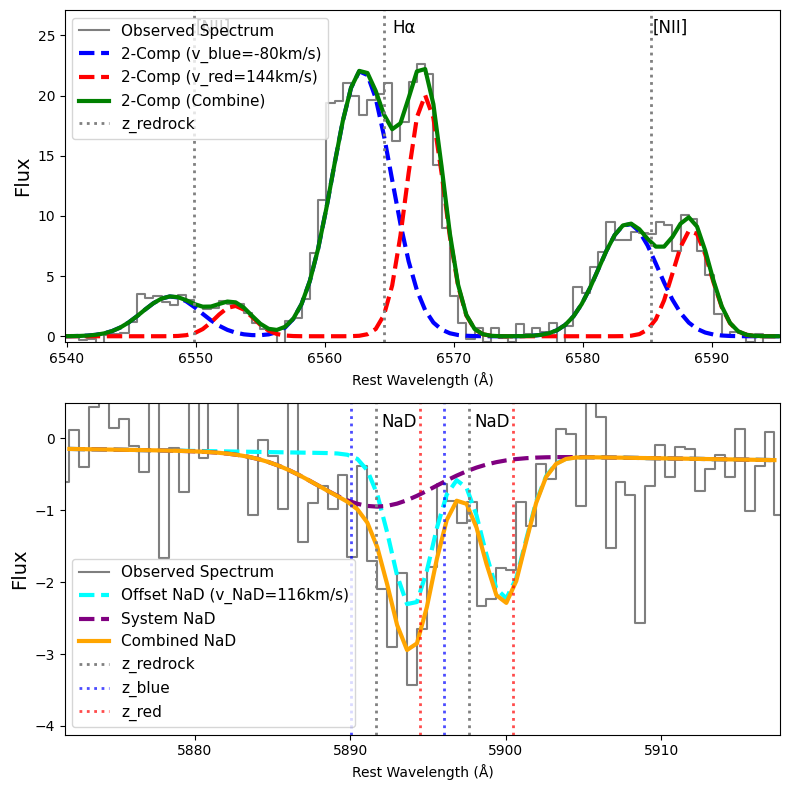

In [546]:
# line_cols = [
#             '[NII]', 'Hα', '[NII]',
#             '[SII]', '[SII]',
#             'NaD', 'NaD']
# lines = [NII_rest[0], *Halpha_rest, NII_rest[1], *SII_rest, *NaD_rest]


line_cols = [
            '[NII]', 'Hα', '[NII]',
            'NaD', 'NaD']
lines = [NII_rest[0], *Halpha_rest, NII_rest[1], *NaD_rest]


# fig, axes = plt.subplots(1, 3, figsize=(20,5), sharey=False)
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharey=False)
plt.subplots_adjust(wspace=-0.8)
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i == 0:
        ax.set_xlim([NII_rest[0]-10, NII_rest[1]+10])
        ax.set_ylabel('Flux', fontsize=14)
        # ax.errorbar(lam, flux, yerr=sigma, label='Observed Spectrum', fmt='o', color='k', markersize=7, alpha=0.4)
        ax.step(lam, flux, label='Observed Spectrum', color='k', alpha=0.5)
        # ax.plot(lam, test_1comp, label='1-Comp', linewidth=3, color='purple')
        ax.plot(lam, test_2comp_l, label=f'2-Comp (v_blue={example_df["dv_l"]:.0f}km/s)', linestyle='--', linewidth=3, color='blue')
        ax.plot(lam, test_2comp_r, label=f'2-Comp (v_red={example_df["dv_r"]:.0f}km/s)', linestyle='--', linewidth=3, color='red')
        ax.plot(lam, test_2comp, label='2-Comp (Combine)', linewidth=3, color='green')
    # if i == 1:
    #     ax.set_xlim([SII_rest[0]-10, SII_rest[1]+10])
    #     ax.errorbar(lam, flux, yerr=sigma, label='Observed Spectrum', fmt='o', color='k', markersize=7, alpha=0.5)
    #     ax.plot(lam, test_1comp, label='1-Comp', linewidth=3, color='purple')
    #     ax.plot(lam, test_2comp_l, label=f'2-Comp (Left: dv={example_df["dv_l"]:.0f}km/s)', linestyle='--', linewidth=3, color='blue')
    #     ax.plot(lam, test_2comp_r, label=f'2-Comp (Right: dv={example_df["dv_r"]:.0f}km/s)', linestyle='--', linewidth=3, color='red')
    #     ax.plot(lam, test_2comp, label='2-Comp (Combine)', linewidth=3, color='green')
    elif i == 1:
        ax.set_ylabel('Flux', fontsize=14)
        ax.set_xlim([NaD_rest[0]-20, NaD_rest[1]+20])
        # ax.errorbar(lam, flux, yerr=sigma, label='Observed Spectrum', fmt='o', color='k', markersize=7, alpha=0.4)
        ax.step(lam, flux, label='Observed Spectrum', color='k', alpha=0.5)
        ax.plot(crop_lam, model_vel(crop_lam, [(popt[0], NaD_rest[0], popt[4], popt[5]), (popt[1], NaD_rest[1], popt[4], popt[5])], (popt[7], (popt[8]))), label=f'Offset NaD (v_NaD={popt[4]:.0f}km/s)', linewidth=3, color='cyan', linestyle='--')
        ax.plot(crop_lam, model_vel(crop_lam, [(popt[2], NaD_rest[0], 0, popt[6]), (popt[3], NaD_rest[1], 0, popt[6])], (popt[7], popt[8])), label=f'System NaD', linewidth=3, color='purple', linestyle='--')
        ax.plot(crop_lam, fitting_func(crop_lam, *popt), label=f'Combined NaD', linewidth=3, color='orange')
        # ax.plot(crop_lam, model_vel(crop_lam, [(popt[0], NaD_rest[0], example_df["dv_l"], popt[5]), (popt[1], NaD_rest[1], example_df["dv_l"], popt[5])], (popt[7], popt[8])), linewidth=3, color='blue', linestyle='--')
        # ax.plot(crop_lam, model_vel(crop_lam, [(popt[0], NaD_rest[0], example_df["dv_r"], popt[5]), (popt[1], NaD_rest[1], example_df["dv_r"], popt[5])], (popt[7], popt[8])), linewidth=3, color='red', linestyle='--')
    for j, line in enumerate(lines):

        if line < ax.get_xlim()[0] or line > ax.get_xlim()[1]:
            continue
        else:
            ax.axvline(x=line, color='gray', linestyle=':', linewidth=2)
            if i !=0:
                ax.axvline(x=line+example_df['dv_l']/c*line, color='blue', linestyle=':', alpha=0.7, linewidth=2)
                ax.axvline(x=line+example_df['dv_r']/c*line, color='red', linestyle=':', alpha=0.7, linewidth=2)
            # if j != 0:
            line_label = f'{line_cols[j]}'
            if i ==0:
                ax.text(line+1.5, np.max(flux[(lam>NII_rest[0]-10) & (lam<NII_rest[1]+10)])*1.1, line_label, color='k', fontsize=12, ha='center', va='bottom')
            # elif i == 1:
            #     ax.text(line+1.5, np.max(flux[(lam>SII_rest[0]-10) & (lam<SII_rest[1]+10)])*1.1, line_label, color='k', fontsize=12, ha='center', va='bottom')
            else:
                ax.text(line+1.5, 0.1, line_label, color='k', fontsize=12, ha='center', va='bottom')
axes[0].axvline(x=0, color='gray', linestyle=':', label='z_redrock', linewidth=2)
axes[0].legend(fontsize=11, loc='upper left')
axes[0].set_ylim(bottom=-0.5, top=np.max(flux[(lam>NII_rest[0]-10) & (lam<NII_rest[1]+10)])*1.2)
axes[0].set_xlabel('Rest Wavelength (Å)')
# axes[1].legend(fontsize=12)
# axes[1].set_ylim(bottom=-0.5, top=np.max(flux[(lam>SII_rest[0]-10) & (lam<SII_rest[1]+10)])*1.2)
# axes[1].set_xlabel('Rest Wavelength (Å)')

axes[1].axvline(x=0, color='gray', linestyle=':', label='z_redrock', linewidth=2)
axes[1].axvline(x=0, color='blue', linestyle=':', label='z_blue', alpha=0.7, linewidth=2)
axes[1].axvline(x=0, color='red', linestyle=':', label='z_red', alpha=0.7, linewidth=2)
axes[1].set_ylim(bottom=np.min(flux[(lam>NaD_rest[0]-15) & (lam<NaD_rest[1]+15)])*1.2, top=0.5)
axes[1].set_xlabel('Rest Wavelength (Å)')
axes[1].legend(fontsize=11, loc='lower left')


plt.tight_layout()
plt.savefig('./figures/plot_spectrum_NaD.png')
plt.show()


In [545]:
# print(image_link(example_df['RA'], example_df['DEC'], plot=True, save_image=True, fname=f"./images/{example_df['TARGETID']}_image.jpg"))
# print(spectrum_link(example_df['TARGETID']))